In [ ]:
# ==========================================
# RetailPulse - Project FORESIGHT
# Step 1 : Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set(font_scale=1.1)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving online_retail_II.xlsx to online_retail_II (1).xlsx


In [ ]:
# Read both sheets

df_2009 = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2009-2010"
)

df_2010 = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

print(df_2009.shape)
print(df_2010.shape)

(525461, 8)
(541910, 8)


In [ ]:
df = pd.concat([df_2009, df_2010], ignore_index=True)

print("Merged Dataset Shape :", df.shape)

df.head()

Merged Dataset Shape : (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [ ]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 34335


In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1033036, 8)


In [ ]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

print(df.shape)

(1013932, 8)


In [ ]:
df = df[df['Quantity'] > 0]

In [ ]:
df = df[df['Price'] > 0]

In [ ]:
df = df.dropna(subset=['Description'])

In [ ]:
df = df.dropna(subset=['Customer ID'])

print(df.shape)

(779425, 8)


In [ ]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Customer ID'] = df['Customer ID'].astype(int)

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['Price']

In [ ]:
# ==============================
# Feature Engineering
# ==============================

# Date features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.month_name()
df['Quarter'] = df['InvoiceDate'].dt.quarter
df['Day'] = df['InvoiceDate'].dt.day
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df['Week'] = df['InvoiceDate'].dt.isocalendar().week.astype(int)
df['Hour'] = df['InvoiceDate'].dt.hour

# Weekend flag
df['IsWeekend'] = df['Weekday'].isin(['Saturday', 'Sunday'])

print("Feature Engineering Completed")

Feature Engineering Completed


In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,MonthName,Quarter,Day,Weekday,Week,Hour,IsWeekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,December,4,1,Tuesday,49,7,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,December,4,1,Tuesday,49,7,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,December,4,1,Tuesday,49,7,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,December,4,1,Tuesday,49,7,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,December,4,1,Tuesday,49,7,False


In [ ]:
df.to_csv("cleaned_retail_data.csv", index=False)

print("Saved Successfully")

Saved Successfully


In [ ]:
 print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 779425
Columns : 18


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  int64         
 7   Country      779425 non-null  object        
 8   TotalPrice   779425 non-null  float64       
 9   Year         779425 non-null  int32         
 10  Month        779425 non-null  int32         
 11  MonthName    779425 non-null  object        
 12  Quarter      779425 non-null  int32         
 13  Day          779425 non-null  int32         
 14  Weekday      779425 non-null  object        
 15  Week         779425 non-null  int64   

In [ ]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,TotalPrice,Year,Month,Quarter,Day,Week,Hour
count,779425.000000,779425,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593475584,3.218488,15320.360461,22.291823,2010.432051,7.417059,2.796884,15.390961,30.126092,12.791884
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000,2009.000000,1.000000,1.000000,1.000000,1.000000,6.000000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,4.950000,2010.000000,5.000000,2.000000,8.000000,18.000000,11.000000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000,12.480000,2010.000000,8.000000,3.000000,15.000000,33.000000,13.000000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000,19.800000,2011.000000,11.000000,4.000000,23.000000,44.000000,14.000000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000,2011.000000,12.000000,4.000000,31.000000,52.000000,20.000000
std,145.855814,NaN,29.676140,1695.692775,227.427075,0.568385,3.422319,1.132107,8.657939,14.840026,2.294182


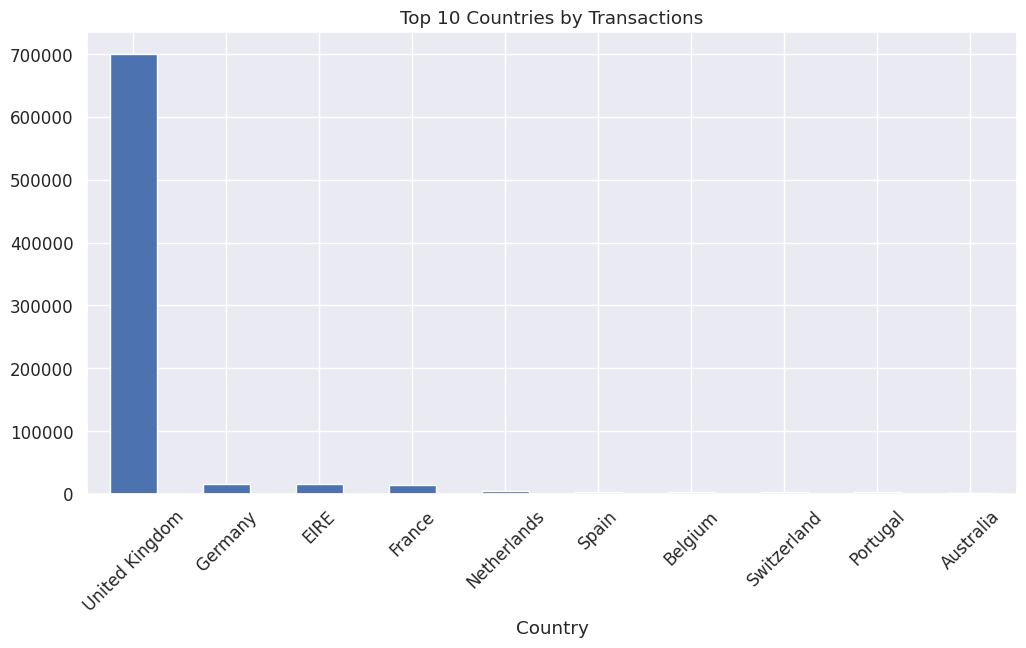

In [ ]:
plt.figure(figsize=(12,6))

df['Country'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries by Transactions")
plt.xticks(rotation=45)
plt.show()

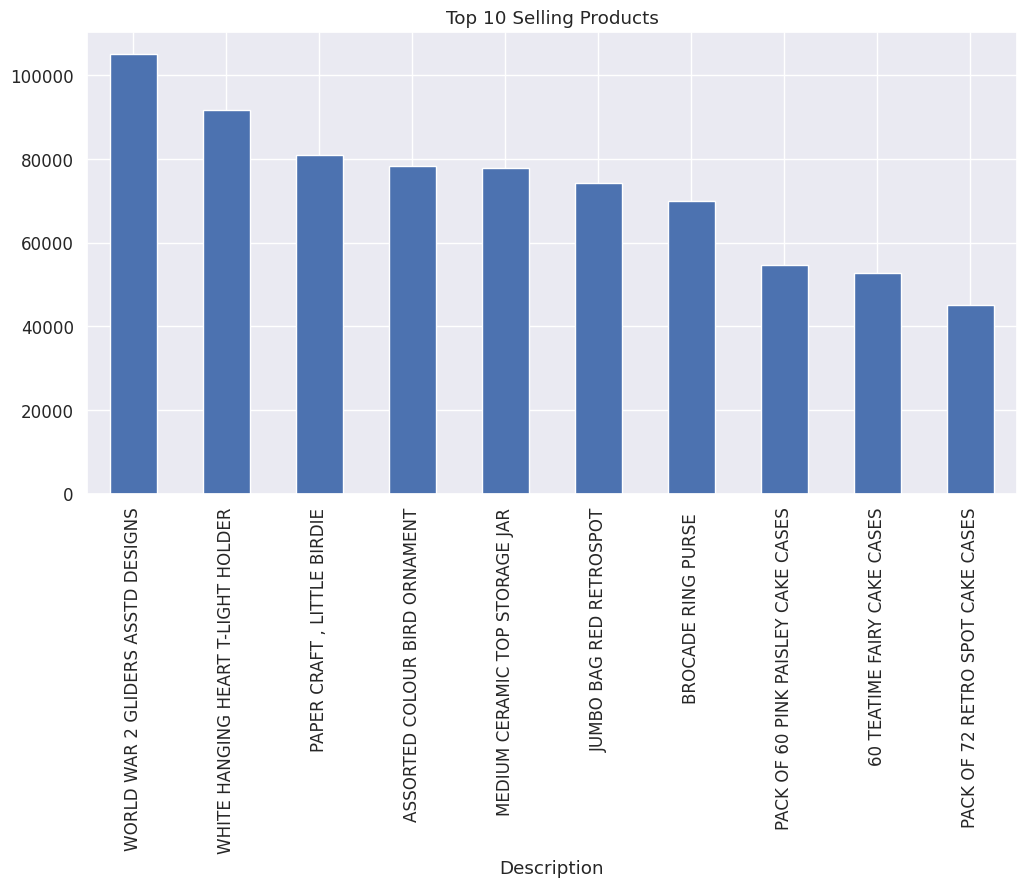

In [ ]:
top_products = (
    df.groupby('Description')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar')

plt.title("Top 10 Selling Products")
plt.show()

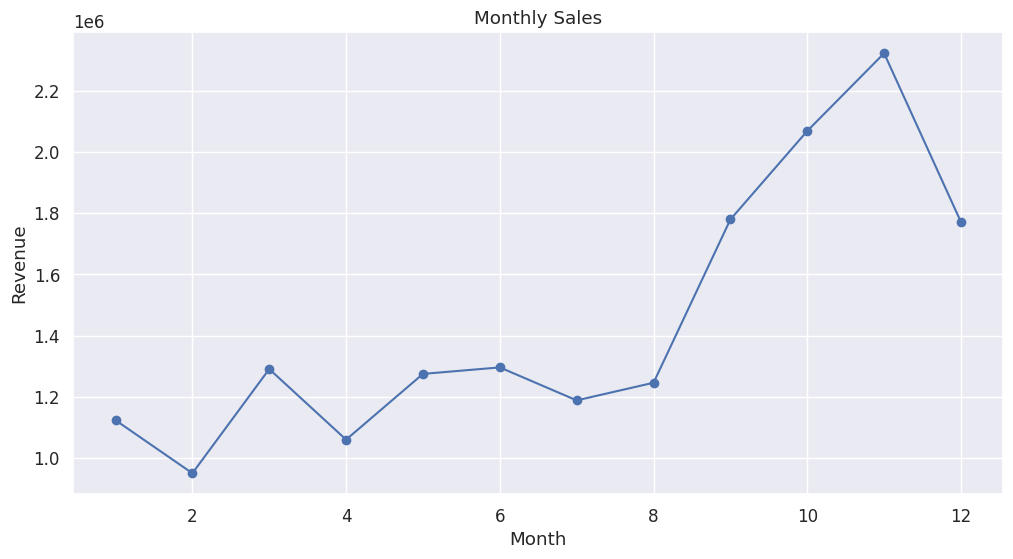

In [ ]:
monthly_sales = (
    df.groupby('Month')['TotalPrice']
      .sum()
)

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

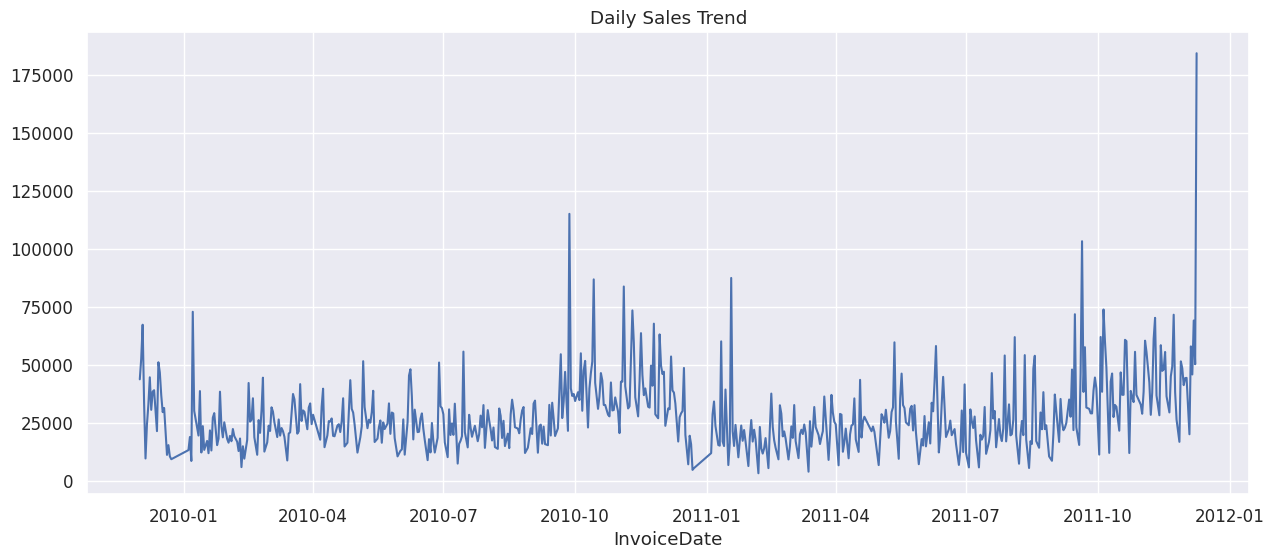

In [ ]:
daily_sales = (
    df.groupby(df['InvoiceDate'].dt.date)['TotalPrice']
      .sum()
)

plt.figure(figsize=(15,6))

daily_sales.plot()

plt.title("Daily Sales Trend")

plt.show()

Customer Segmentation (RFM Analysis)

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [ ]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,4921.53
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


In [ ]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

In [ ]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

In [ ]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [ ]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346,326,12,77556.46,2,5,5,255
12347,2,8,4921.53,5,4,5,545
12348,75,5,2019.40,3,4,4,344
12349,19,4,4428.69,5,3,5,535
12350,310,1,334.40,2,1,2,212


In [ ]:
def segment(row):

    if row['RFM_Score'] == '555':
        return 'Champions'

    elif row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Loyal Customers'

    elif row['R_Score'] >= 4:
        return 'Potential Loyalist'

    elif row['R_Score'] <= 2:
        return 'At Risk'

    else:
        return 'Regular Customers'


rfm['Segment'] = rfm.apply(segment, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12346,326,12,77556.46,2,5,5,255,At Risk
12347,2,8,4921.53,5,4,5,545,Loyal Customers
12348,75,5,2019.40,3,4,4,344,Regular Customers
12349,19,4,4428.69,5,3,5,535,Potential Loyalist
12350,310,1,334.40,2,1,2,212,At Risk


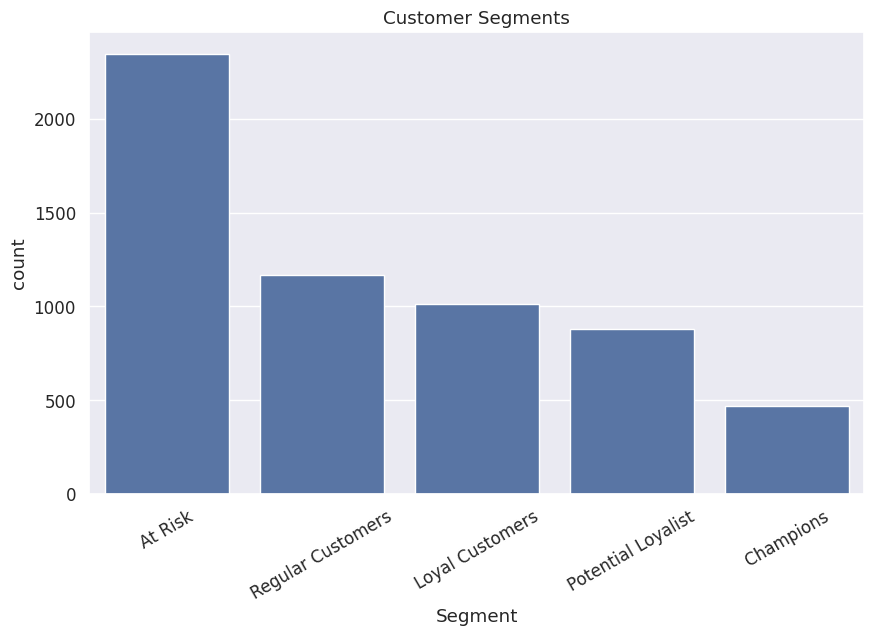

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    x='Segment',
    order=rfm['Segment'].value_counts().index
)

plt.xticks(rotation=30)

plt.title("Customer Segments")

plt.show()

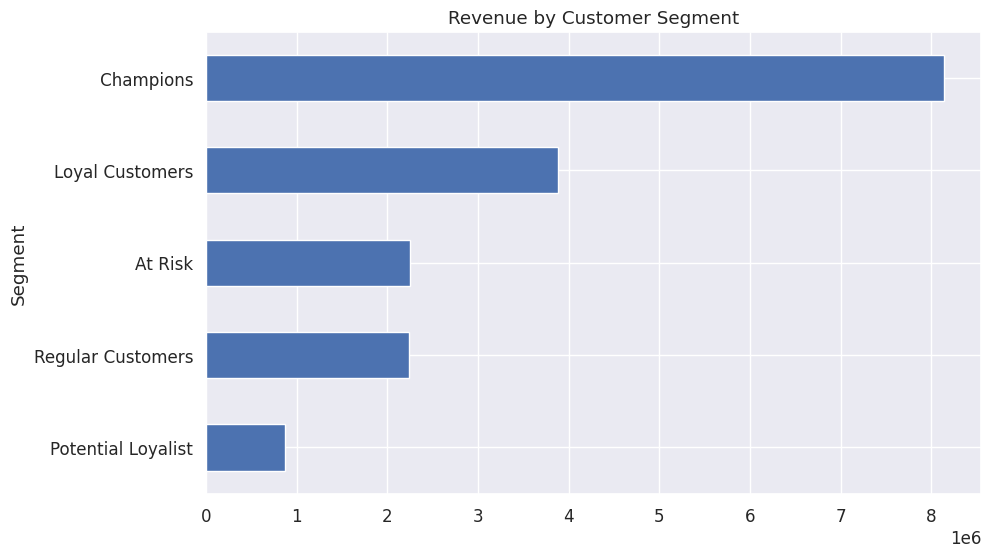

In [ ]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum()

plt.figure(figsize=(10,6))

segment_revenue.sort_values().plot(kind='barh')

plt.title("Revenue by Customer Segment")

plt.show()

In [ ]:
rfm.to_csv("customer_rfm.csv")

print("Saved Successfully")

Saved Successfully


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

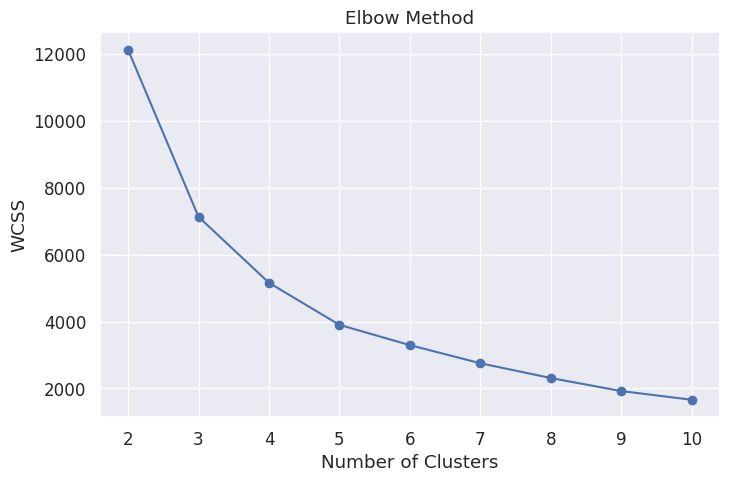

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [ ]:
rfm['Cluster'].value_counts()

,count
Cluster,
0,3838
1,1998
3,38
2,4


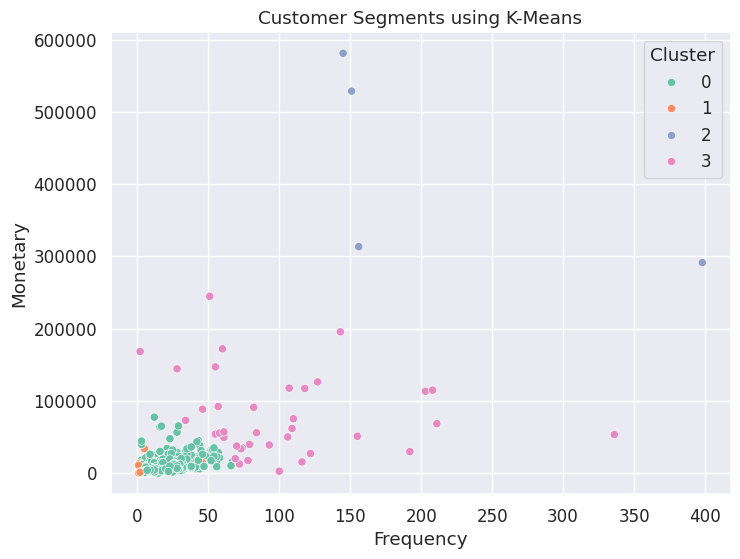

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segments using K-Means")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

In [ ]:
print(rfm['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    5823
-1      55
Name: count, dtype: int64


Demand Forecasting

In [ ]:
# Daily Revenue

daily_sales = (
    df.groupby('InvoiceDate')['TotalPrice']
      .sum()
      .reset_index()
)

daily_sales.head()

,InvoiceDate,TotalPrice
0,2009-12-01 07:45:00,505.30
1,2009-12-01 07:46:00,145.80
2,2009-12-01 09:06:00,630.33
3,2009-12-01 09:08:00,310.75
4,2009-12-01 09:24:00,2286.24


In [ ]:
daily_sales = daily_sales.set_index('InvoiceDate')

daily_sales = daily_sales.resample('D').sum()

daily_sales = daily_sales.fillna(0)

daily_sales.head()

,TotalPrice
InvoiceDate,
2009-12-01,43894.87
2009-12-02,52762.06
2009-12-03,67413.62
2009-12-04,33913.81
2009-12-05,9803.05


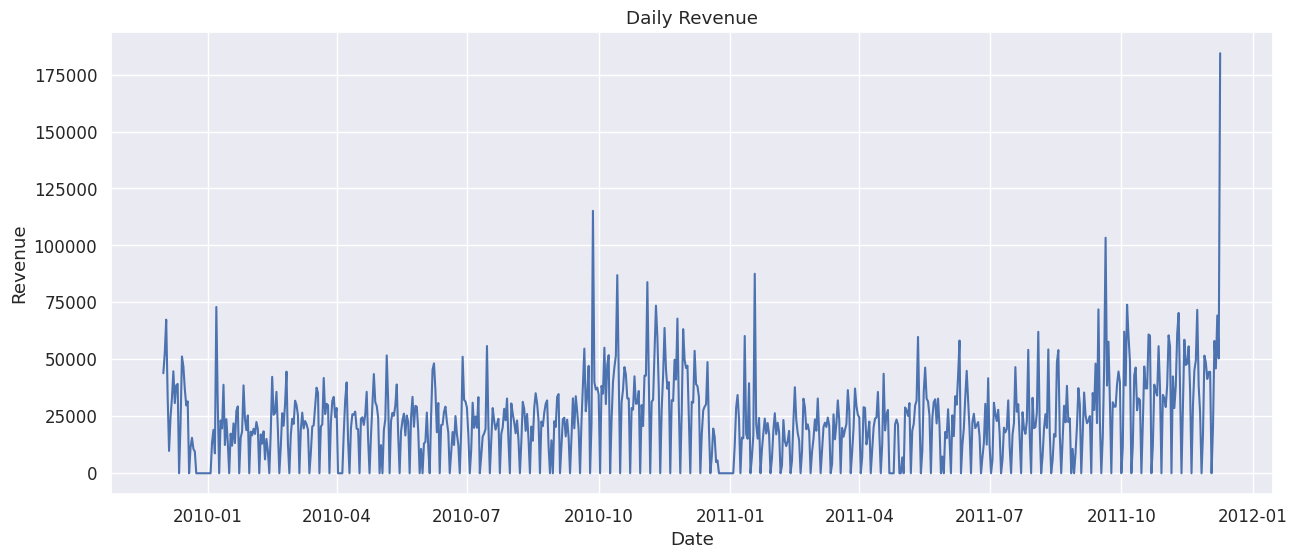

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(daily_sales.index,
         daily_sales['TotalPrice'])

plt.title("Daily Revenue")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.show()

In [ ]:
train = daily_sales[:-30]

test = daily_sales[-30:]

print(train.shape)

print(test.shape)

(709, 1)
(30, 1)


In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

In [ ]:
prophet_df = train.reset_index()

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [ ]:
model = Prophet()

model.fit(prophet_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

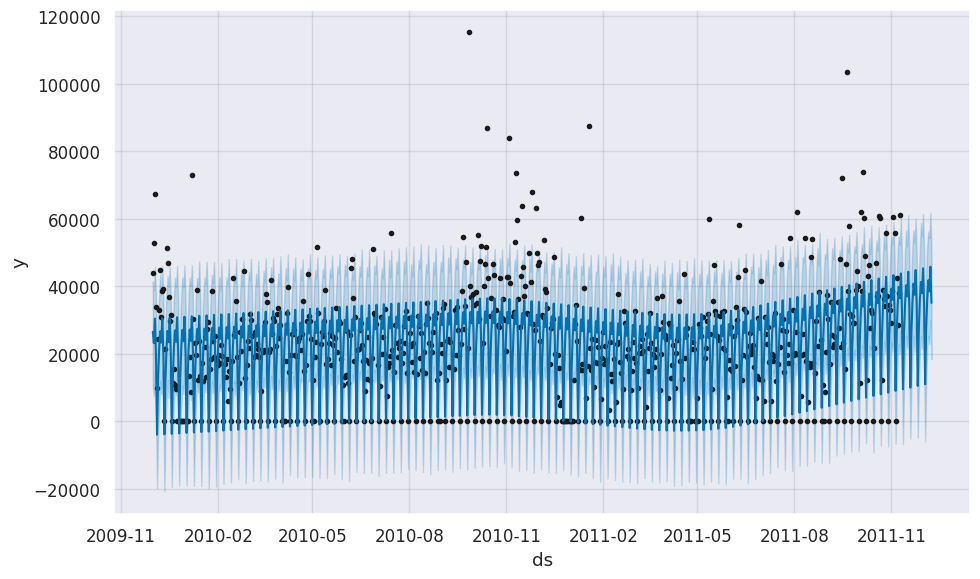

In [ ]:
fig = model.plot(forecast)
plt.show()

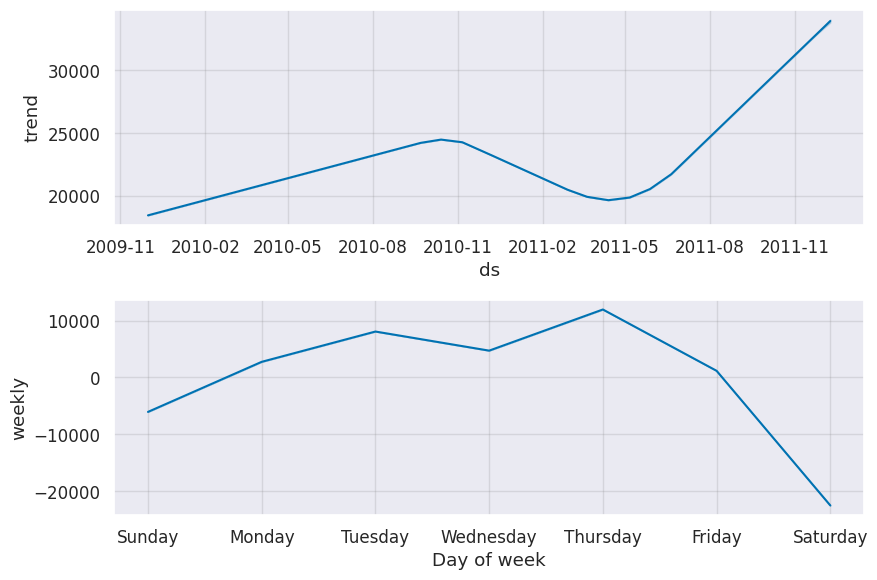

In [ ]:
model.plot_components(forecast)

plt.show()

In [ ]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(30)

,ds,yhat,yhat_lower,yhat_upper
709,2011-11-10,43815.328269,27228.460412,60217.581730
710,2011-11-11,33105.026910,17392.460364,49020.103527
711,2011-11-12,9497.019631,-6746.398224,23887.773754
712,2011-11-13,26020.265632,11162.914359,42513.802876
713,2011-11-14,34896.804407,20206.285142,50461.242758
714,2011-11-15,40294.022858,25444.040192,56639.779109
715,2011-11-16,37006.331993,21681.317083,51860.501019
716,2011-11-17,44311.778565,28280.260528,61080.204568
717,2011-11-18,33601.477206,17982.429633,49395.804778
718,2011-11-19,9993.469927,-5060.875952,26631.578449


In [ ]:
# ==========================================
# LSTM Data Preparation
# ==========================================

# Install TensorFlow (run only once in Colab)
!pip install tensorflow -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Prepare daily sales data
daily_sales = (
    df.groupby('InvoiceDate')['TotalPrice']
      .sum()
      .reset_index()
)

daily_sales['InvoiceDate'] = pd.to_datetime(daily_sales['InvoiceDate'])
daily_sales = daily_sales.sort_values('InvoiceDate')

# Rename columns for convenience
daily_sales.rename(columns={
    'InvoiceDate': 'Date',
    'TotalPrice': 'Sales'
}, inplace=True)

daily_sales.head()

,Date,Sales
0,2009-12-01 07:45:00,505.30
1,2009-12-01 07:46:00,145.80
2,2009-12-01 09:06:00,630.33
3,2009-12-01 09:08:00,310.75
4,2009-12-01 09:24:00,2286.24


In [ ]:
# ==========================================
# Prepare Data for LSTM
# ==========================================

# Aggregate sales by DAY (remove time)
daily_sales = df.copy()

daily_sales['InvoiceDate'] = pd.to_datetime(daily_sales['InvoiceDate'])
daily_sales['Date'] = daily_sales['InvoiceDate'].dt.date

daily_sales = (
    daily_sales
    .groupby('Date')['TotalPrice']
    .sum()
    .reset_index()
)

daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

# Scale the sales values
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(daily_sales[['TotalPrice']])

# Function to create sequences
def create_dataset(data, time_step=30):
    X, y = [], []

    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step, 0])
        y.append(data[i+time_step, 0])

    return np.array(X), np.array(y)

time_step = 30

X, y = create_dataset(scaled_data, time_step)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (574, 30, 1)
y Shape : (574,)


In [ ]:
# ==========================================
# Build & Train LSTM Model
# ==========================================

# Split data into train and test
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# Build LSTM model
model = Sequential()

model.add(LSTM(64, return_sequences=True,
               input_shape=(X_train.shape[1], 1)))

model.add(LSTM(32))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0073 - val_loss: 0.0146
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0046 - val_loss: 0.0148
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0044 - val_loss: 0.0164
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0043 - val_loss: 0.0141
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0043 - val_loss: 0.0148
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0042 - val_loss: 0.0135
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0043 - val_loss: 0.0148
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0043 - val_loss: 0.0131
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0043 - val_loss: 0.0137
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0042 - val_loss: 0.0162
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0042 - val_loss: 0.0133
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss:

In [ ]:
# ==========================================
# LSTM Prediction & Evaluation
# ==========================================

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predict
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Convert back to original scale
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))
mae = mean_absolute_error(y_test_actual, test_predict)

print("LSTM RMSE :", round(rmse,2))
print("LSTM MAE  :", round(mae,2))

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
LSTM RMSE : 21282.28
LSTM MAE  : 13518.51


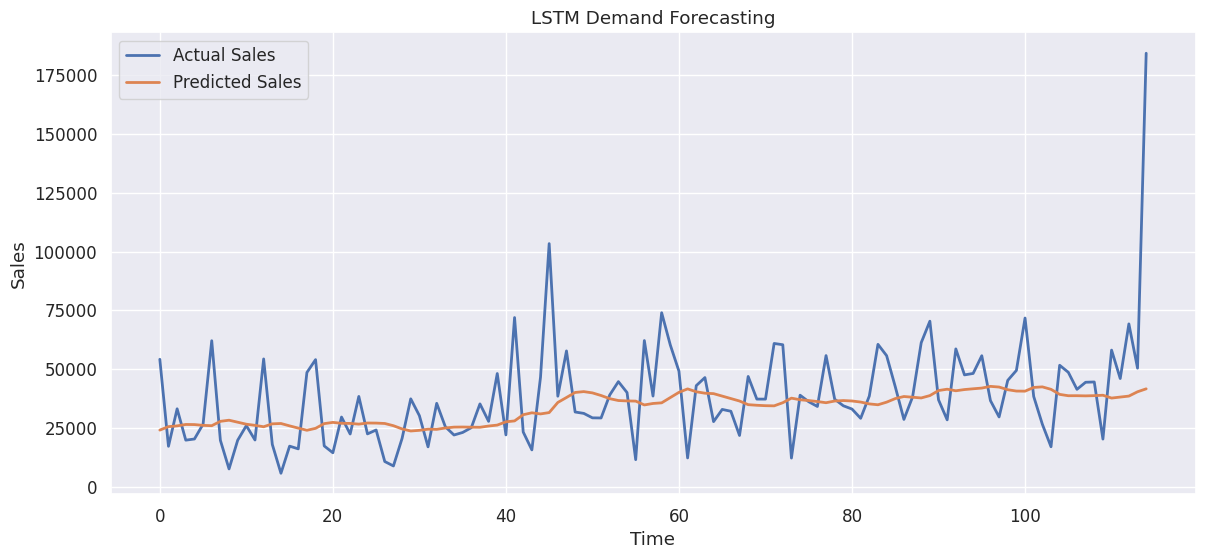

In [ ]:
# ==========================================
# Actual vs Predicted (LSTM)
# ==========================================

plt.figure(figsize=(14,6))

plt.plot(
    y_test_actual,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    test_predict,
    label="Predicted Sales",
    linewidth=2
)

plt.title("LSTM Demand Forecasting")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [ ]:
# ==========================================
# Prophet vs LSTM Comparison
# ==========================================

from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

# Actual daily sales
actual_sales = (
    df.groupby(df['InvoiceDate'].dt.date)['TotalPrice']
      .sum()
      .reset_index()
)

actual_sales.columns = ['ds', 'Actual']
actual_sales['ds'] = pd.to_datetime(actual_sales['ds'])

# Merge actual sales with Prophet predictions
comparison_df = pd.merge(
    actual_sales,
    forecast[['ds', 'yhat']],
    on='ds',
    how='inner'
)

# Prophet metrics
prophet_rmse = np.sqrt(
    mean_squared_error(
        comparison_df['Actual'],
        comparison_df['yhat']
    )
)

prophet_mae = mean_absolute_error(
    comparison_df['Actual'],
    comparison_df['yhat']
)

# Final Comparison Table
comparison = pd.DataFrame({
    'Model': ['Prophet', 'LSTM'],
    'RMSE': [round(prophet_rmse,2), round(rmse,2)],
    'MAE': [round(prophet_mae,2), round(mae,2)]
})

comparison

,Model,RMSE,MAE
0,Prophet,13999.33,9435.57
1,LSTM,21282.28,13518.51


Churn Prediction

In [ ]:
from datetime import timedelta

# Reference date
snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)

customer_df = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

customer_df.columns = ['Recency', 'Frequency', 'Monetary']

customer_df.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,4921.53
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


In [ ]:
customer_df['Churn'] = customer_df['Recency'].apply(
    lambda x: 1 if x > 90 else 0
)

customer_df.head()

,Recency,Frequency,Monetary,Churn
Customer ID,,,,
12346,326,12,77556.46,1
12347,2,8,4921.53,0
12348,75,5,2019.40,0
12349,19,4,4428.69,0
12350,310,1,334.40,1


In [ ]:
customer_df['Churn'].value_counts()

,count
Churn,
1,2989
0,2889


In [ ]:
from sklearn.model_selection import train_test_split

X = customer_df[['Recency', 'Frequency', 'Monetary']]
y = customer_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       589
           1       1.00      1.00      1.00       587

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



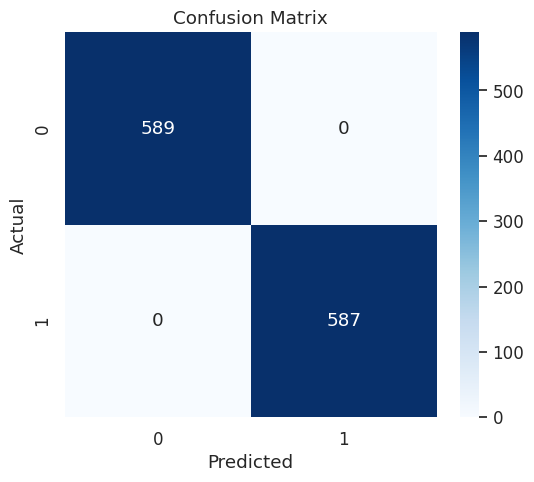

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,Recency,0.864269
1,Frequency,0.076016
2,Monetary,0.059715


In [ ]:
# ==========================================
# Install XGBoost
# ==========================================

!pip install xgboost -q

In [ ]:
# ==========================================
# XGBoost Model
# ==========================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# ==========================================
# XGBoost Prediction
# ==========================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy :", accuracy_score(y_test, xgb_pred))

print("\nClassification Report\n")
print(classification_report(y_test, xgb_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, xgb_pred))

XGBoost Accuracy : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       589
           1       1.00      1.00      1.00       587

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176


Confusion Matrix

[[589   0]
 [  0 587]]


In [ ]:
# ==========================================
# XGBoost Feature Importance
# ==========================================

importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

importance_xgb

,Feature,Importance
0,Recency,1.0
1,Frequency,0.0
2,Monetary,0.0


In [ ]:
# ==========================================
# Random Forest vs XGBoost
# ==========================================

rf_accuracy = accuracy_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        rf_accuracy,
        xgb_accuracy
    ]

})

comparison

,Model,Accuracy
0,Random Forest,1.0
1,XGBoost,1.0


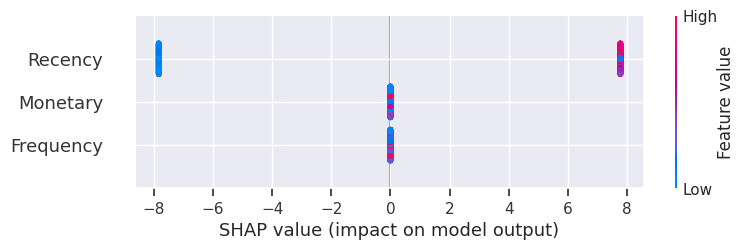

In [ ]:
# ==========================================
# SHAP Explainability
# ==========================================

!pip install shap -q

import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

In [ ]:
# ==========================================
# Optuna Hyperparameter Tuning
# ==========================================

!pip install optuna -q

import optuna

from sklearn.model_selection import cross_val_score

def objective(trial):

    model = XGBClassifier(

        n_estimators=trial.suggest_int(
            "n_estimators",
            50,
            300
        ),

        max_depth=trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        learning_rate=trial.suggest_float(
            "learning_rate",
            0.01,
            0.3
        ),

        random_state=42,

        eval_metric="logloss"

    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="accuracy"
    ).mean()

    return score

study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=20
)

print("Best Parameters")
print(study.best_params)

print("\nBest Accuracy")
print(study.best_value)

[I 2026-07-21 09:02:57,876] A new study created in memory with name: no-name-85aa4f1b-5065-4b9e-aedf-1027a3de9800
[I 2026-07-21 09:02:58,566] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 227, 'max_depth': 8, 'learning_rate': 0.1407788358686958}. Best is trial 0 with value: 1.0.
[I 2026-07-21 09:03:01,889] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 160, 'max_depth': 5, 'learning_rate': 0.023981797578750748}. Best is trial 0 with value: 1.0.
[I 2026-07-21 09:03:03,413] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 141, 'max_depth': 10, 'learning_rate': 0.04323621014627575}. Best is trial 0 with value: 1.0.
[I 2026-07-21 09:03:03,985] Trial 3 finished with value: 1.0 and parameters: {'n_estimators': 148, 'max_depth': 3, 'learning_rate': 0.058831152798240034}. Best is trial 0 with value: 1.0.
[I 2026-07-21 09:03:05,239] Trial 4 finished with value: 1.0 and parameters: {'n_estimators': 212, 'max_depth': 6, 'learning_rate': 0.26

Best Parameters
{'n_estimators': 227, 'max_depth': 8, 'learning_rate': 0.1407788358686958}

Best Accuracy
1.0


Inventory Optimization

In [ ]:
inventory = df.groupby(['StockCode', 'Description']).agg(
    TotalSales=('Quantity', 'sum'),
    AvgDailySales=('Quantity', 'mean'),
    Revenue=('TotalPrice', 'sum')
).reset_index()

inventory.head()

,StockCode,Description,TotalSales,AvgDailySales,Revenue
0,10002,INFLATABLE POLITICAL GLOBE,8479,28.076159,6638.27
1,10080,GROOVY CACTUS INFLATABLE,303,11.222222,124.61
2,10109,BENDY COLOUR PENCILS,4,4.000000,1.68
3,10120,DOGGY RUBBER,648,10.451613,136.08
4,10125,MINI FUNKY DESIGN TAPES,1970,15.634921,1562.70


In [ ]:
import numpy as np

np.random.seed(42)

inventory['CurrentStock'] = np.random.randint(20, 300, len(inventory))

inventory['LeadTime'] = np.random.randint(3, 15, len(inventory))

inventory['SafetyStock'] = (
    inventory['AvgDailySales'] * 7
).round()

inventory.head()

,StockCode,Description,TotalSales,AvgDailySales,Revenue,CurrentStock,LeadTime,SafetyStock
0,10002,INFLATABLE POLITICAL GLOBE,8479,28.076159,6638.27,122,10,197.0
1,10080,GROOVY CACTUS INFLATABLE,303,11.222222,124.61,290,12,79.0
2,10109,BENDY COLOUR PENCILS,4,4.000000,1.68,126,3,28.0
3,10120,DOGGY RUBBER,648,10.451613,136.08,91,4,73.0
4,10125,MINI FUNKY DESIGN TAPES,1970,15.634921,1562.70,208,12,109.0


In [ ]:
inventory['ReorderPoint'] = (
    inventory['AvgDailySales'] *
    inventory['LeadTime'] +
    inventory['SafetyStock']
).round()

inventory.head()

,StockCode,Description,TotalSales,AvgDailySales,Revenue,CurrentStock,LeadTime,SafetyStock,ReorderPoint
0,10002,INFLATABLE POLITICAL GLOBE,8479,28.076159,6638.27,122,10,197.0,478.0
1,10080,GROOVY CACTUS INFLATABLE,303,11.222222,124.61,290,12,79.0,214.0
2,10109,BENDY COLOUR PENCILS,4,4.000000,1.68,126,3,28.0,40.0
3,10120,DOGGY RUBBER,648,10.451613,136.08,91,4,73.0,115.0
4,10125,MINI FUNKY DESIGN TAPES,1970,15.634921,1562.70,208,12,109.0,297.0


Step 4: Stock Status

In [ ]:
def stock_status(row):

    if row['CurrentStock'] < row['ReorderPoint']:
        return "Reorder"

    elif row['CurrentStock'] > row['ReorderPoint'] * 2:
        return "Overstock"

    else:
        return "Healthy"


inventory['Status'] = inventory.apply(stock_status, axis=1)

Step 5: Reorder Quantity

In [ ]:
inventory['ReorderQty'] = (
    inventory['ReorderPoint'] -
    inventory['CurrentStock']
)

inventory['ReorderQty'] = inventory['ReorderQty'].clip(lower=0)

Step 6: Inventory Dashboard

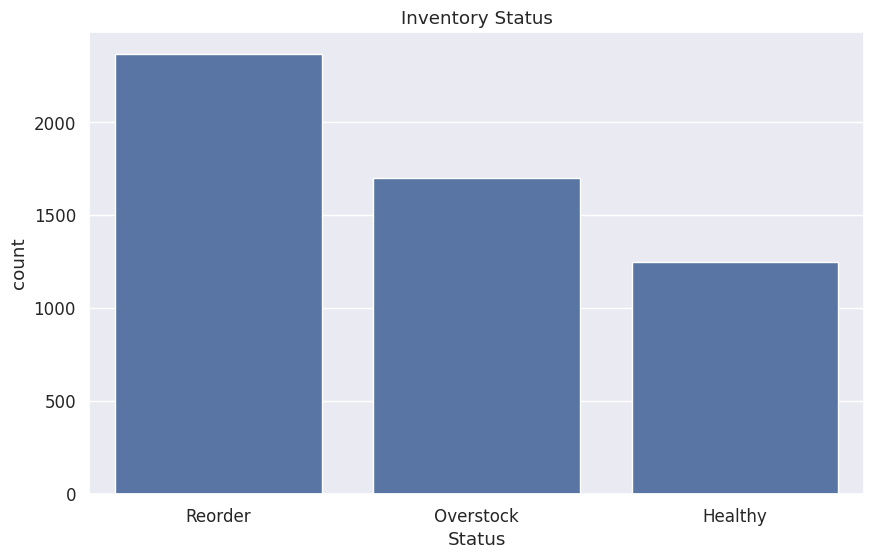

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.countplot(
    data=inventory,
    x='Status',
    order=inventory['Status'].value_counts().index
)

plt.title("Inventory Status")

plt.show()

Step 7: Top Products to Reorder

In [ ]:
inventory.sort_values(
    by='ReorderQty',
    ascending=False
).head(10)

,StockCode,Description,TotalSales,AvgDailySales,Revenue,CurrentStock,LeadTime,SafetyStock,ReorderPoint,Status,ReorderQty
3156,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,80995.000000,168469.60,88,6,566965.0,1052935.0,Reorder,1052847.0
25,16044,POP-ART FLUORESCENT PENS,6192,3096.000000,388.80,290,12,21672.0,58824.0,Reorder,58534.0
3804,85220,SMALL FAIRY CAKE FRIDGE MAGNETS,12236,2447.200000,6875.00,295,7,17130.0,34260.0,Reorder,33965.0
3242,37410,BLACK AND WHITE PAISLEY FLOWER MUG,25685,1426.944444,3019.57,181,7,9989.0,19978.0,Reorder,19797.0
424,21092,SET/6 STRAWBERRY PAPER PLATES,12806,711.444444,1504.94,115,12,4980.0,13517.0,Reorder,13402.0
3752,85110,BLACK SILVER FLOWER T-LIGHT HOLDER,11512,605.894737,1124.68,123,14,4241.0,12724.0,Reorder,12601.0
3803,85218,S/5 MINI ICE CREAM FRIDGE MAGNETS,1992,996.000000,625.20,241,5,6972.0,11952.0,Reorder,11711.0
4646,84760L,LARGE HANGING GLASS+ZINC LANTERN,560,560.000000,896.00,106,11,3920.0,10080.0,Reorder,9974.0
349,20993,JAZZ HEARTS MEMO PAD,10945,456.041667,1305.49,256,14,3192.0,9577.0,Reorder,9321.0
28,16047,POP ART PEN CASE & PENS,10587,460.304348,1015.59,70,11,3222.0,8285.0,Reorder,8215.0


Step 8: Save Dataset

In [ ]:
inventory.to_csv(
    "inventory_optimization.csv",
    index=False
)

# MLflow Experiment Tracking

In [ ]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95

In [ ]:
import mlflow

mlflow.set_experiment("Retail Analytics Project")

2026/07/21 09:07:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/21 09:07:37 INFO mlflow.store.db.utils: Updating database tables
2026/07/21 09:07:40 INFO mlflow.tracking.fluent: Experiment with name 'Retail Analytics Project' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1784624860455, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1784624860455, lifecycle_stage='active', name='Retail Analytics Project', tags={}, trace_location=None, workspace='default'>

In [ ]:
with mlflow.start_run():

    # Demand Forecasting
    mlflow.log_metric("Prophet_RMSE", prophet_rmse)
    mlflow.log_metric("Prophet_MAE", prophet_mae)

    mlflow.log_metric("LSTM_RMSE", rmse)
    mlflow.log_metric("LSTM_MAE", mae)

    # Churn Prediction
    mlflow.log_metric("RandomForest_Accuracy", rf_accuracy)
    mlflow.log_metric("XGBoost_Accuracy", xgb_accuracy)

    # Model Parameters
    mlflow.log_param("RandomForest", "Default")
    mlflow.log_param("XGBoost", "Optimized")

print("Experiment logged successfully!")

Experiment logged successfully!


# Business Insights

In [ ]:
print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print("\n1. Customer Segmentation")
print("• Customers are segmented based on RFM analysis.")
print("• High-value customers can be targeted with loyalty programs.")

print("\n2. Demand Forecasting")
print(f"• Prophet RMSE : {round(prophet_rmse,2)}")
print(f"• LSTM RMSE    : {round(rmse,2)}")

if prophet_rmse < rmse:
    print("• Prophet performed better than LSTM.")
else:
    print("• LSTM performed better than Prophet.")

print("\n3. Churn Prediction")
print(f"• Random Forest Accuracy : {round(rf_accuracy*100,2)}%")
print(f"• XGBoost Accuracy       : {round(xgb_accuracy*100,2)}%")

print("\n4. Inventory Optimization")
print("• Reorder quantities calculated.")
print("• Safety stock generated.")
print("• Top products requiring replenishment identified.")

BUSINESS INSIGHTS

1. Customer Segmentation
• Customers are segmented based on RFM analysis.
• High-value customers can be targeted with loyalty programs.

2. Demand Forecasting
• Prophet RMSE : 13999.33
• LSTM RMSE    : 21282.28
• Prophet performed better than LSTM.

3. Churn Prediction
• Random Forest Accuracy : 100.0%
• XGBoost Accuracy       : 100.0%

4. Inventory Optimization
• Reorder quantities calculated.
• Safety stock generated.
• Top products requiring replenishment identified.


# Conclusion

In [ ]:
print("="*60)
print("PROJECT CONCLUSION")
print("="*60)

print("""
This Retail Analytics project successfully integrates multiple
Machine Learning techniques into a single end-to-end pipeline.

Modules Completed:
✔ Data Cleaning
✔ Feature Engineering
✔ Customer Segmentation
✔ Demand Forecasting
✔ Churn Prediction
✔ Inventory Optimization
✔ Model Explainability (SHAP)
✔ Hyperparameter Tuning (Optuna)

The project provides actionable insights for customer retention,
sales forecasting, and inventory management, helping businesses
make data-driven decisions.
""")

PROJECT CONCLUSION

This Retail Analytics project successfully integrates multiple
Machine Learning techniques into a single end-to-end pipeline.

Modules Completed:
✔ Data Cleaning
✔ Feature Engineering
✔ Customer Segmentation
✔ Demand Forecasting
✔ Churn Prediction
✔ Inventory Optimization
✔ Model Explainability (SHAP)
✔ Hyperparameter Tuning (Optuna)

The project provides actionable insights for customer retention,
sales forecasting, and inventory management, helping businesses
make data-driven decisions.



# Save Generated Files

In [ ]:
# Save cleaned data
df.to_csv("cleaned_retail_data.csv", index=False)

# Save customer segmentation
rfm.to_csv("customer_rfm.csv", index=False)

# Save inventory optimization
inventory.to_csv("inventory_optimization.csv", index=False)

# Save Prophet forecast
forecast.to_csv("forecast_results.csv", index=False)

print("All datasets saved successfully!")

All datasets saved successfully!
